#EDA and Preprocessing

In [1]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
df=pd.read_csv('/content/drive/MyDrive/creditcard.csv')

In [3]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


#Without Balancing

In [4]:
x=df.drop(['Time','Class'],axis=1)
y=df.Class

In [5]:
from sklearn.model_selection import train_test_split


In [6]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=123,stratify=y)

#Linear regression

In [7]:
from sklearn.linear_model import LogisticRegression

#KNN

In [8]:
from sklearn.neighbors import KNeighborsClassifier

In [9]:
knn=KNeighborsClassifier(n_neighbors=5)

In [10]:
knn.fit(x_train,y_train)

KNeighborsClassifier()

In [11]:
y_pred=knn.predict(x_test)

In [12]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [13]:
print(confusion_matrix(y_test,y_pred))

[[85287     8]
 [   58    90]]


In [14]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.92      0.61      0.73       148

    accuracy                           1.00     85443
   macro avg       0.96      0.80      0.87     85443
weighted avg       1.00      1.00      1.00     85443



#Undersampling

In [15]:
# now we are balancing imbalanced data
#imb= imbalance
from imblearn.under_sampling import NearMiss

In [16]:
nm=NearMiss()

In [17]:
# us means undersampling
x_us,y_us=nm.fit_resample(x,y)

In [18]:

x_us.shape

(984, 29)

In [19]:
count=y_us.value_counts()

In [20]:
count

,count
Class,
0,492
1,492


<Axes: xlabel='Class', ylabel='count'>

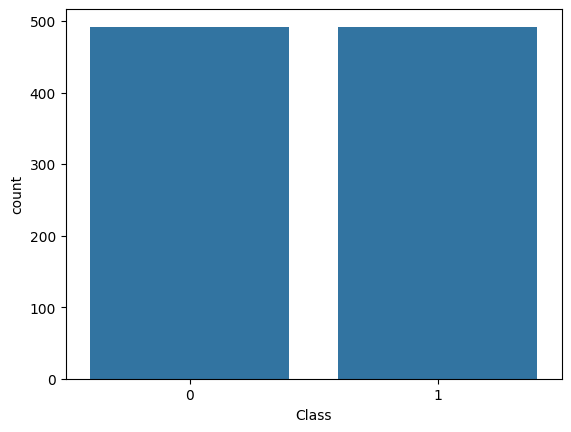

In [21]:
import seaborn as sns
sns.countplot(x=y_us)

In [22]:
y_pred=knn.predict(x_test)

In [23]:
confusion_matrix(y_test,y_pred)

array([[85287,     8],
       [   58,    90]])

#Oversampling

In [24]:
# SMOTE (synthetic minority oversampling tech.)
from imblearn.over_sampling import SMOTE

In [25]:
os=SMOTE()

In [26]:
x_os,y_os=os.fit_resample(x,y)

In [27]:
x_os.shape

(568630, 29)

In [28]:
count=y_os.value_counts()

In [29]:
count

,count
Class,
0,284315
1,284315


<Axes: xlabel='Class', ylabel='count'>

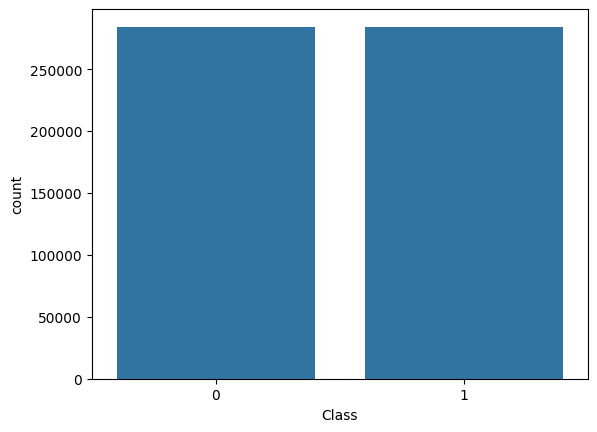

In [30]:
import seaborn as sns
sns.countplot(x=y_os)

In [31]:
x_train,x_test,y_train,y_test=train_test_split(x_os,y_os,test_size=0.1,random_state=123,stratify=y_os)

In [32]:
knn.fit(x_train,y_train)

KNeighborsClassifier()

In [33]:
y_pred=knn.predict(x_test)

In [34]:
confusion_matrix(y_test,y_pred)

array([[28341,    91],
       [    0, 28431]])

In [35]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [36]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28432
           1       1.00      1.00      1.00     28431

    accuracy                           1.00     56863
   macro avg       1.00      1.00      1.00     56863
weighted avg       1.00      1.00      1.00     56863

